In [1]:
import numpy as np
import pandas as pd
import torch
from numpy.ma.core import reshape
from sympy.printing.pytorch import torch
from sympy.tensor import tensor
from torch.fx.experimental.migrate_gradual_types.z3_types import dim
from unstructured.partition import model_init

In [2]:
torch.__version__

'2.11.0+cu126'

In [3]:
t1 = torch.tensor([1,2])
t1

tensor([1, 2])

In [4]:
t1.dtype

torch.int64

In [5]:
np1 = np.array([1,2])
t2 = torch.tensor(np1)
t2

tensor([1, 2])

In [6]:
t2.dtype,np1.dtype

(torch.int64, dtype('int64'))

In [7]:
t3 = torch.tensor([1.1,2.2])
t3

tensor([1.1000, 2.2000])

In [8]:
t3.dtype

torch.float32

In [9]:
t4 = torch.tensor(np.array([1.1,2.2]))
t4

tensor([1.1000, 2.2000], dtype=torch.float64)

In [10]:
t4.dtype

torch.float64

In [11]:
t = torch.tensor(1)
t

tensor(1)

In [12]:
t.flatten()

tensor([1])

In [13]:
t

tensor(1)

In [14]:
t = torch.tensor([1,2])
t

tensor([1, 2])

In [15]:
t.reshape([2])

tensor([1, 2])

In [16]:
print(t.reshape([1,2]))

tensor([[1, 2]])


In [17]:
print(t.reshape([1,1,2]))

tensor([[[1, 2]]])


In [18]:
print(t.reshape([1,1,1,2]))

tensor([[[[1, 2]]]])


In [19]:
t.reshape([1,1,1,2]).ndim

4

In [20]:
a1 = np.array([[1, 2, 2], [3, 4, 4]])
a1

array([[1, 2, 2],
       [3, 4, 4]])

In [21]:
a2 = np.array([[5, 6, 6], [7, 8, 8]])
a2

array([[5, 6, 6],
       [7, 8, 8]])

In [22]:
# 由两个形状相同的二维数组创建一个三维的张量
t3 = torch.tensor([a1, a2])
t3

C:\Users\ROG\AppData\Local\Temp\ipykernel_11576\574442481.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  t3 = torch.tensor([a1, a2])


tensor([[[1, 2, 2],
         [3, 4, 4]],

        [[5, 6, 6],
         [7, 8, 8]]])

In [23]:
t3.shape

torch.Size([2, 2, 3])

In [24]:
t3.reshape(-1)

tensor([1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 8])

In [25]:
t3.flatten()

tensor([1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 8])

In [26]:
# 序列生成
t_seq1 = torch.arange(1, 10, 2)    # tensor([1, 3, 5, 7, 9])
t_seq2 = torch.linspace(1, 10, 4)  # tensor([1.0000, 4.0000, 7.0000, 10.0000])

# 常量填充
t_0 = torch.zeros(2, 2)            # 2x2 的全 0 张量
t_1 = torch.ones(1, 3)             # 1x3 的全 1 张量，tensor([[1., 1., 1.]])
t_empty = torch.empty(2, 2)        # 2x2 的未初始化张量(占用现有内存垃圾值，速度极快)
t_full = torch.full((2, 3), 9.9)   # 2行3列，全部填满 9.9 的张量

# 线性代数
t_eye = torch.eye(3)               # 3x3 的单位矩阵 (主对角线为1)
t_diag1 = torch.diag(torch.tensor([1, 2, 3])) # 传入1D: 生成主对角线为 1,2,3 的 3x3 对角阵
t_diag2 = torch.diag(t_eye)        # 传入2D: 提取刚才 t_eye 的对角线元素 -> tensor([1., 1., 1.])

# 随机分布
t_rand = torch.rand(2, 2)          # 2x2，元素在 [0, 1) 间的均匀分布随机张量
t_randn = torch.randn(2, 2)        # 2x2，标准正态分布随机张量 (常用于初始化网络权重)
t_int = torch.randint(0, 10, (2,2))# 2x2，元素在 [0, 10) 间的随机整数张量
t_norm = torch.normal(0, 1, size=(2, 3)) # 生成一个均值为 0，标准差为 1 的 2x3 随机张量

In [27]:
t_seq1.dtype,t_seq2.dtype

(torch.int64, torch.float32)

In [28]:
print(t_eye)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [29]:
t = torch.normal(75,6,(25,))

In [30]:
t = torch.arange(10)
t

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [31]:
id(t)

2410983462608

In [32]:
t1 = t[1:8]
t1

tensor([1, 2, 3, 4, 5, 6, 7])

In [33]:
id(t1)

2410983619744

In [34]:
t1 = torch.arange(1, 11)
t2 = torch.arange(1, 10).reshape(3, 3)
t3 = torch.arange(1, 28).reshape(3, 3, 3)

# 1. 一维索引与切片
res1 = t1[0]           # 提取第一个元素 (依然返回0维张量)
res2 = t1[1:8:2]       # 从第2个到第8个，每隔2个取一个，返回 tensor([2, 4, 6, 8])

# 2. 二维索引 (逗号分隔行与列)
res3 = t2[0, 1]        # 索引第一行、第二列的元素
res4 = t2[::2, ::2]    # 每隔两行取一行，且每一行中每隔两个元素取一个

# 3. 三维索引
res5 = t3[1, 1, 1]     # 索引第二个矩阵中，第二行、第二列的元素
res6 = t3[1, 2, ::2]   # 索引第二个矩阵，第三行，列方向每隔两个取一个

In [35]:
res3

tensor(2)

In [37]:
print(res4)

tensor([[1, 3],
        [7, 9]])


In [38]:
print(res5)

tensor(14)


In [39]:
print(res6)

tensor([16, 18])


In [40]:
t2 = torch.arange(12).reshape(4, 3)

# 准备用于索引的 Tensor 对象 (假设要提取位置序号为 1 和 2 的数据)
indices = torch.tensor([1, 2])

# 1. 在第 0 维度 (行) 上进行索引提取
res_row = torch.index_select(t2, dim=0, index=indices)
# 等同于提取第 2 行和第 3 行的数据

# 2. 在第 1 维度 (列) 上进行索引提取
res_col = torch.index_select(t2, dim=1, index=indices)
# 等同于提取第 2 列和第 3 列的数据

In [42]:
print(t2)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


In [43]:
print(res_row)

tensor([[3, 4, 5],
        [6, 7, 8]])


In [44]:
print(res_row)

tensor([[3, 4, 5],
        [6, 7, 8]])


In [45]:
print(res_col)

tensor([[ 1,  2],
        [ 4,  5],
        [ 7,  8],
        [10, 11]])


In [47]:
t = torch.arange(6)
t

tensor([0, 1, 2, 3, 4, 5])

In [49]:
te = t.view(2,3)
te

tensor([[0, 1, 2],
        [3, 4, 5]])

In [50]:
id(t)

2410983472288

In [51]:
id(te)

2409973659392

In [52]:
t[0]=100

In [53]:
t

tensor([100,   1,   2,   3,   4,   5])

In [54]:
te

tensor([[100,   1,   2],
        [  3,   4,   5]])

In [55]:
t2 = torch.arange(12).reshape(4, 3)

# 1. 均分切分(沿着0轴分成4份)
res_chunks = torch.chunk(t2, 4, dim=0)
# 返回包含4个张量的元组，每个形状为[1, 3]

# 2. 无法均分时的次一级切分
res_unmatched = torch.chunk(t2, 3, dim=0)
# 总行数是4，要求分3份。系统按向上取整方式：前1份包含2行，后1份包含2行，总共返回2个张量

In [56]:
print(res_chunks)

(tensor([[0, 1, 2]]), tensor([[3, 4, 5]]), tensor([[6, 7, 8]]), tensor([[ 9, 10, 11]]))


In [57]:
print(res_unmatched)

(tensor([[0, 1, 2],
        [3, 4, 5]]), tensor([[ 6,  7,  8],
        [ 9, 10, 11]]))


In [59]:
res_chunks

(tensor([[0, 1, 2]]),
 tensor([[3, 4, 5]]),
 tensor([[6, 7, 8]]),
 tensor([[ 9, 10, 11]]))

In [58]:
res_unmatched

(tensor([[0, 1, 2],
         [3, 4, 5]]),
 tensor([[ 6,  7,  8],
         [ 9, 10, 11]]))

In [61]:
print(t2)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


In [62]:
t2.shape

torch.Size([4, 3])

In [66]:
t2 = torch.arange(12).reshape(4, 3)  # 总共有 4 行

# 1. 指定每块的行数为2进行均分
res_even = torch.split(t2, 2, dim=0)

# 2. 按照[1, 3]列表不均匀切分 (1+3=4，符合总行数)
res_custom = torch.split(t2, [1, 3], dim=0)
# 返回元组: 第一个张量含1行，第二个张量含3行

In [68]:
print(t2)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


In [69]:
res_even

(tensor([[0, 1, 2],
         [3, 4, 5]]),
 tensor([[ 6,  7,  8],
         [ 9, 10, 11]]))

In [70]:
res_custom

(tensor([[0, 1, 2]]),
 tensor([[ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]]))

In [72]:
a = torch.zeros(2, 3)  # 生成一个 2行3列 的全 0 张量
b = torch.ones(2, 3)   # 生成一个 2行3列 的全 1 张量
c = torch.zeros(3, 3)  # 生成一个 3行3列 的全 0 张量
# 1. cat 拼接 (同维度首尾连接)
res_cat_row = torch.cat([a, b], dim=0)    # 竖向拼接，变成 [4, 3] 形状
res_cat_col = torch.cat([a, b], dim=1)    # 横向拼接，变成 [2, 6] 形状
res_cat_diff = torch.cat([a, c], dim=0)   # 竖向拼接，a与c列数同为3，不报错，变成 [5, 3]

# 2. stack 堆叠 (增加全新维度)
res_stack = torch.stack([a, b], dim=0)    # 变成三维张量，形状升为 [2, 2, 3]

# 3. 严格形状要求对比
# torch.cat([a, c], dim=1)                # 报错！横向拼时，行数 2 和 3 不匹配！
# torch.stack([a, c], dim=0)              # 报错！堆叠要求双方整体形状必须绝对相同！

In [75]:
print(res_cat_row)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [77]:
print(res_cat_col)

tensor([[0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.]])


In [78]:
print(res_cat_diff)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [79]:
print(res_stack)

tensor([[[0., 0., 0.],
         [0., 0., 0.]],

        [[1., 1., 1.],
         [1., 1., 1.]]])


In [80]:
res_stack.shape

torch.Size([2, 2, 3])

In [2]:
t3 = torch.zeros(3, 2, 2)  # 形状 (3, 2, 2)
t_2d = torch.ones(3, 2)    # 形状 (2, 2)
t3,t_2d

(tensor([[[0., 0.],
          [0., 0.]],
 
         [[0., 0.],
          [0., 0.]],
 
         [[0., 0.],
          [0., 0.]]]),
 tensor([[1., 1.],
         [1., 1.],
         [1., 1.]]))

In [3]:
res4 = t3 + t_2d           # t_2d 隐式转化为 (3, 1, 2) 后广播计算
res4

RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1

In [1]:
import numpy as np
import pandas as pd
import torch
torch.pow(torch.tensor(2), 2)

tensor(4)

In [2]:
t = torch.arange(12).float().reshape(3, 4)
# tensor([[ 0.,  1.,  2.,  3.],
#         [ 4.,  5.,  6.,  7.],
#         [ 8.,  9., 10., 11.]])
res_sum = torch.sum(t, dim=0)      # 沿行压缩，按列求和: tensor([12., 15., 18., 21.])

In [5]:
res_max = torch.max(t, dim=0)

In [6]:
res_max

torch.return_types.max(
values=tensor([ 8.,  9., 10., 11.]),
indices=tensor([2, 2, 2, 2]))

In [2]:
t3 = torch.arange(24).float().reshape(2, 3, 4)
# tensor([[[ 0.,  1.,  2.,  3.],
#          [ 4.,  5.,  6.,  7.],
#          [ 8.,  9., 10., 11.]],
#
#         [[12., 13., 14., 15.],
#          [16., 17., 18., 19.],
#          [20., 21., 22., 23.]]])
t3

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])

In [3]:
torch.sum(t3, dim = 0)
# tensor([[12., 14., 16., 18.],
#         [20., 22., 24., 26.],
#         [28., 30., 32., 34.]])

tensor([[12., 14., 16., 18.],
        [20., 22., 24., 26.],
        [28., 30., 32., 34.]])

In [6]:
torch.sum(t3, dim = 1)
# tensor([[12., 15., 18., 21.],
#         [48., 51., 54., 57.]])

tensor([[12., 15., 18., 21.],
        [48., 51., 54., 57.]])


In [9]:
torch.sum(t3, dim=2)
# tensor([[ 6., 22., 38.],
#         [54., 70., 86.]])

tensor([[ 6., 22., 38.],
        [54., 70., 86.]])


In [11]:
t3.shape

torch.Size([2, 3, 4])

In [13]:
t3.ndim

3

In [12]:
torch.sum(t3, dim = 1).ndim

2

In [15]:
t = torch.arange(12).float().reshape(3, 4)
res_sort = torch.sort(t, dim=1)
res_sort
# torch.return_types.sort(
# values=tensor([[ 0.,  1.,  2.,  3.],
#                [ 4.,  5.,  6.,  7.],
#                [ 8.,  9., 10., 11.]]),
# indices=tensor([[0, 1, 2, 3],
#                 [0, 1, 2, 3],
#                 [0, 1, 2, 3]]))

torch.return_types.sort(
values=tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]]),
indices=tensor([[0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 1, 2, 3]]))

In [3]:
t = torch.arange(11,-1,-1).float().reshape(3, 4)
res_sort = torch.sort(t, dim=1)
res_sort

torch.return_types.sort(
values=tensor([[ 8.,  9., 10., 11.],
        [ 4.,  5.,  6.,  7.],
        [ 0.,  1.,  2.,  3.]]),
indices=tensor([[3, 2, 1, 0],
        [3, 2, 1, 0],
        [3, 2, 1, 0]]))

In [1]:
import numpy as np
import pandas as pd
import torch
t = torch.tensor([[1,2,3],[4,5,6]]).float()

In [4]:
t.trace()

tensor(6.)

In [2]:
A = torch.arange(1, 10).reshape(3, 3).float()
A

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [3]:
# 1. 特征分解 (eig & eigh)
A = torch.tensor([[1., 2.],
                  [2., 4.]]) # 这是一个对称矩阵
# 推荐写法：使用 eigh 处理对称矩阵，直接得到纯实数结果
torch.linalg.eigh(A)

torch.return_types.linalg_eigh(
eigenvalues=tensor([0., 5.]),
eigenvectors=tensor([[-0.8944,  0.4472],
        [ 0.4472,  0.8944]]))

In [5]:
C = torch.tensor([[1., 2., 3.],
                  [2., 4., 6.],
                  [3., 6., 9.]])

U, S, Vh = torch.linalg.svd(C)

In [8]:
U @ torch.diag(S) @ Vh

tensor([[1.0000, 2.0000, 3.0000],
        [2.0000, 4.0000, 6.0000],
        [3.0000, 6.0000, 9.0000]])


In [2]:
x = np.arange(-1,3,0.05)
y = np.arange(-1,3,0.05)
a, b = np.meshgrid(x, y)
SSE = (2 - a - b) ** 2 + (4 - 3 * a - b) ** 2

In [3]:
x.astype(np.int_)

array([-1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2])

In [12]:
y

array([-1.0000000e+00, -9.5000000e-01, -9.0000000e-01, -8.5000000e-01,
       -8.0000000e-01, -7.5000000e-01, -7.0000000e-01, -6.5000000e-01,
       -6.0000000e-01, -5.5000000e-01, -5.0000000e-01, -4.5000000e-01,
       -4.0000000e-01, -3.5000000e-01, -3.0000000e-01, -2.5000000e-01,
       -2.0000000e-01, -1.5000000e-01, -1.0000000e-01, -5.0000000e-02,
        8.8817842e-16,  5.0000000e-02,  1.0000000e-01,  1.5000000e-01,
        2.0000000e-01,  2.5000000e-01,  3.0000000e-01,  3.5000000e-01,
        4.0000000e-01,  4.5000000e-01,  5.0000000e-01,  5.5000000e-01,
        6.0000000e-01,  6.5000000e-01,  7.0000000e-01,  7.5000000e-01,
        8.0000000e-01,  8.5000000e-01,  9.0000000e-01,  9.5000000e-01,
        1.0000000e+00,  1.0500000e+00,  1.1000000e+00,  1.1500000e+00,
        1.2000000e+00,  1.2500000e+00,  1.3000000e+00,  1.3500000e+00,
        1.4000000e+00,  1.4500000e+00,  1.5000000e+00,  1.5500000e+00,
        1.6000000e+00,  1.6500000e+00,  1.7000000e+00,  1.7500000e+00,
      

In [4]:
np.meshgrid(x, y)

AttributeError: 'tuple' object has no attribute 'shape'

In [1]:
import torch

# 1. 准备通用数据结构
# 假设 X_raw 为原始特征，我们需要在末尾拼接一列全 1 来捕捉截距 b
X = torch.tensor([[1., 1.],    # 样本1: 特征x1=1, 常数项=1
                  [3., 1.]])   # 样本2: 特征x1=3, 常数项=1
y = torch.tensor([[2.],
                  [4.]])       # 真实值列向量 y

# 2. 根据正规方程解析解 w = (X^T * X)^-1 * X^T * y 进行求解
# 使用 @ 运算符 (torch.matmul) 替代繁琐的 torch.mm，代码更现代
w = torch.linalg.inv(X.T @ X) @ X.T @ y

print("最优参数解:\n", w)
# 输出结果将对应参数 [w_1, b]^T

最优参数解:
 tensor([[1.0000],
        [1.0000]])


In [2]:
torch.linalg.lstsq(X,y)

torch.return_types.linalg_lstsq(
solution=tensor([[1.0000],
        [1.0000]]),
residuals=tensor([]),
rank=tensor(2),
singular_values=tensor([]))

In [3]:
# 构造一个 5个样本，2个特征(包含截距) 的超定系统
X_feat = torch.tensor([[1., 1.],
                       [2., 1.],
                       [3., 1.],
                       [4., 1.],
                       [5., 1.]])
# 故意制造一些噪音，让它们不在一条直线上
y_true = torch.tensor([[2.1],
                       [3.9],
                       [6.2],
                       [8.1],
                       [9.8]])

result = torch.linalg.lstsq(X_feat, y_true,driver='gels')

print("最优参数解 (solution):\n", result.solution)
print("残差平方和 (residuals):\n", result.residuals)

最优参数解 (solution):
 tensor([[1.9600],
        [0.1400]])
残差平方和 (residuals):
 tensor([0.0920])


In [4]:
# 1. 定义需优化的参数，并允许自动求导
a = torch.tensor(1., requires_grad=True)
b = torch.tensor(1., requires_grad=True)

# 2. 构建目标函数 (前向传播建立计算图)
sse = torch.pow((2 - a - b), 2) + torch.pow((4 - 3 * a - b), 2)

# 3. 验证偏导数是否为 0
# torch.autograd.grad 是通用微分函数，当输入多个自变量时计算偏导数
grads = torch.autograd.grad(sse, [a, b])
print(grads)

(tensor(-0.), tensor(-0.))


In [6]:
# 1. 定义自变量并允许自动求导 (requires_grad=True 极其重要)
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)

# 2. 构建前向计算图: y = w * x^2
y = w * (x ** 2)

# 3. 求解 y 对 w 和 x 的偏导数
# 理论数学解：
# dy/dw = x^2 = 2^2 = 4
# dy/dx = 2 * w * x = 2 * 3 * 2 = 12
torch.autograd.grad(outputs=y, inputs=[w, x])


(tensor(4.), tensor(12.))

In [15]:
import torch
import numpy as np

In [6]:
x = torch.tensor(1.,requires_grad=True)
x

tensor(1., requires_grad=True)

In [8]:
y = x**2
y

tensor(1., grad_fn=<PowBackward0>)

In [16]:
x = torch.tensor(1.,requires_grad=True)
y = x**2
z = y + 1
z.backward()
x.grad

tensor(2.)

In [1]:
import torch

In [4]:
# 以MSE均方误差为例
# 1. 准备数据和模型
# 点(1,2),(2,4)；模型:y=wx+b
# X：第1列是特征x，第2列是常数项 1
X = torch.tensor([[1.,1],
                 [2,1]],requires_grad=True)
y = torch.tensor([[2.],
                 [4]],requires_grad=True)
w = torch.tensor([[0.],
                  [0]],requires_grad=True)
# 2. 设置超参数
lr = 0.1
epochs = 1000
# 3. 迭代训练
for i in range(epochs):
    loss = torch.mean(torch.pow((y - X@w),2))
    loss.backward()

    with torch.no_grad():
        w -= lr*w.grad
        w.grad.zero_()

print("训练后的权重 [w1, b]^T:\n", w)

训练后的权重 [w1, b]^T:
 tensor([[2.0000e+00],
        [1.6615e-06]], requires_grad=True)


In [9]:
import torch
def LinearR(X,w):
    z_hat = X@w
    return z_hat

# z_hat = w1*x1 + w2*x2 + b
X = torch.tensor([[1.,0,0],
                  [1,1,0],
                  [1,0,1],
                  [1,1,1]],requires_grad=True)
z = torch.tensor([[-0.2],
                  [-0.05],
                  [-0.05],
                  [0.1]],requires_grad=True)
# w = torch.zeros(3,1,requires_grad=True)
w = torch.tensor([[-0.2],
                  [0.15],
                  [0.15]],requires_grad=True)
z_hat = LinearR(X,w)
# z_hat == z
torch.sum((z - z_hat)**2)

tensor(8.3267e-17, grad_fn=<SumBackward0>)

In [10]:
# 创建一个 100x100 的大矩阵
big_tensor = torch.randn(100, 100)

# 1. 默认打印会显示省略号 ...
print("默认打印:\n", big_tensor)

# 2. 强行改变打印规则：保留2位小数，且绝对不截断显示！
torch.set_printoptions(precision=2, threshold=float('inf'))
print("修改规则后打印:\n", big_tensor) # 此时会满屏打印所有 10000 个元素

# 3. 用完后恢复 PyTorch 的默认设置 (好习惯)
torch.set_printoptions(profile="default")

默认打印:
 tensor([[-1.3840, -1.2492,  0.6762,  ...,  1.5979, -1.7582, -0.2823],
        [ 0.4981, -1.1073, -0.9235,  ..., -0.3036,  0.3311,  0.5786],
        [-0.9422, -0.2717,  2.1143,  ..., -0.3625, -0.4068, -0.5136],
        ...,
        [ 1.1565,  0.5502, -0.7146,  ..., -0.0374,  1.2774,  0.4224],
        [ 0.3920,  1.2613, -1.2283,  ...,  0.4899, -0.7182, -0.0208],
        [-1.4335, -0.2543, -0.0262,  ..., -1.0005, -0.2518,  0.2897]])
修改规则后打印:
 tensor([[-1.38e+00, -1.25e+00,  6.76e-01, -3.80e-01, -5.23e-01,  1.97e+00,
         -7.33e-02,  5.87e-01, -2.67e-01, -4.59e-01,  1.07e+00,  1.36e+00,
         -1.05e+00, -4.84e-01, -6.59e-01, -5.15e-01, -1.64e-01, -8.65e-02,
         -2.56e-02,  3.68e-01, -7.23e-01,  9.38e-01, -1.62e+00,  2.25e-02,
         -8.51e-01,  1.33e+00,  7.87e-01, -6.41e-01, -1.63e+00,  4.62e-01,
         -5.94e-01, -5.02e-01, -5.46e-01,  1.14e-01,  5.35e-01, -3.40e-01,
          1.48e-01, -1.03e+00,  2.17e-01,  1.73e-02, -2.23e-01, -1.39e+00,
          5.27e-01, -1.0

In [14]:
import torch
from torch import nn as nn

torch.manual_seed(420)

# z_hat = w1*x1 + w2*x2 + b
X = torch.tensor([[0.,0],
                  [1,0],
                  [0,1],
                  [1,1]],requires_grad=True)
z = torch.tensor([[-0.2],
                  [-0.05],
                  [-0.05],
                  [0.1]],requires_grad=True)

z_hat = nn.Linear(in_features=2,out_features=1)

In [15]:
z_hat.weight

Parameter containing:
tensor([[ 0.4318, -0.4256]], requires_grad=True)

In [16]:
z_hat.bias

Parameter containing:
tensor([0.6730], requires_grad=True)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 0. 固定随机种子，保证每次运行生成的初始权重 W 和偏置 b 一致
torch.manual_seed(42)

# 第一部分：模拟真实的逻辑回归前向传播 (nn.Linear + Sigmoid)
# 1. 准备输入特征 X (m=2个样本, n=3个特征)
X = torch.tensor([[1., 0., 0.],
                  [1., 1., 0.]])

# 2. 实例化线性层 (in_features=3, out_features=1)
# 这一步自动创建了权重 W (1, 3) 和偏置 b (1,)
output_layer = nn.Linear(3, 1)

# 3. 计算线性组合 z (回归阶段)
# 底层执行: z = X @ W.T + b
z_hat = output_layer(X)
print("1.线性层输出 z_hat:\n", z_hat, "\n")

# 4. 通过 Sigmoid 激活函数将其转化为概率(分类阶段)
# 推荐使用torch.sigmoid()或F.sigmoid()
prob = torch.sigmoid(z_hat)

print("2.经过Sigmoid后的概率输出 prob:", prob)
# prob 中的值代表样本属于类别 '1' 的概率 (0 到 1 之间)

1.线性层输出 z_hat:
 tensor([[0.9718],
        [1.4510]], grad_fn=<AddmmBackward0>) 

2.经过Sigmoid后的概率输出 prob: tensor([[0.7255],
        [0.8101]], grad_fn=<SigmoidBackward0>)


In [21]:
import torch
def LogisticR(X,w):
    z_hat = X@w
    sigmoid = (1+torch.exp(-z_hat))**(-1)
    andhant =torch.tensor([int(x) for x in sigmoid>0.5],dtype=torch.float32) #列表推导式
    return sigmoid,andhant

X = torch.tensor([[1., 0., 0.],[1,1,0],[1,0,1],[1,1,1]],requires_grad=True)
andgate = torch.tensor([[0.],[0],[0],[1]],requires_grad=True)
w = torch.tensor([[-0.2],[0.15],[0.15]],requires_grad=True)

LogisticR(X,w)

(tensor([[0.4502],
         [0.4875],
         [0.4875],
         [0.5250]], grad_fn=<PowBackward0>),
 tensor([0., 0., 0., 1.]))

In [23]:
X = torch.tensor([[1,0,0],
                  [1,1,0],
                  [1,0,1],
                  [1,1,1]], dtype = torch.float32)
andgate = torch.tensor([[0],
                        [0],
                        [0],
                        [1]], dtype = torch.float32)
w = torch.tensor([-0.2,0.15, 0.15], dtype = torch.float32)

def LinearRwithsign(X,w):
    zhat = X@w
    andhat = torch.tensor([int(x) for x in zhat >= 0], dtype = torch.float32)
    return zhat, andhat

LinearRwithsign(X,w)

(tensor([-0.2000, -0.0500, -0.0500,  0.1000]), tensor([0., 0., 0., 1.]))

In [25]:
import torch
import torch.nn.functional as F

# 1. 模拟神经网络对 2 个样本的 3 分类原始输出 (Logits)
# 形状为 (2, 3)，代表 2 个样本，每个样本的 3 个类别得分
logits = torch.tensor([[1.0, 2.0, 3.0],    # 样本1得分接近
                       [100.0, 10.0, -10.0]]) # 样本2得分差距极大
logits.shape

torch.Size([2, 3])

In [31]:
import torch
from torch import nn as nn
import torch.nn.functional as F
torch.manual_seed(420)
X = torch.tensor([[0,0],
                  [1,0],
                  [0,1],
                  [1,1]], dtype = torch.float32)
dense = nn.Linear(2,3)

In [32]:
dense(X)

tensor([[ 0.5453,  0.2653, -0.3527],
        [ 0.9772,  0.9382, -0.5684],
        [ 0.1197, -0.2964, -0.8400],
        [ 0.5516,  0.3765, -1.0557]], grad_fn=<AddmmBackward0>)

In [33]:
dense.weight

Parameter containing:
tensor([[ 0.4318, -0.4256],
        [ 0.6730, -0.5617],
        [-0.2157, -0.4873]], requires_grad=True)

In [34]:
dense.bias

Parameter containing:
tensor([ 0.5453,  0.2653, -0.3527], requires_grad=True)

In [44]:
print((X @ dense.weight[0]).reshape(-1, 1)+ dense.bias[0])

tensor([[0.5453],
        [0.9772],
        [0.1197],
        [0.5516]], grad_fn=<AddBackward0>)


In [45]:
dense(X).shape

torch.Size([4, 3])

In [47]:
torch.softmax(dense(X),dim=1)

tensor([[0.4623, 0.3494, 0.1883],
        [0.4598, 0.4422, 0.0980],
        [0.4896, 0.3229, 0.1875],
        [0.4902, 0.4115, 0.0983]], grad_fn=<SoftmaxBackward0>)

In [50]:
torch.tensor([x.sum() for x in torch.softmax(dense(X),dim=1)])

C:\Users\ROG\AppData\Local\Temp\ipykernel_30292\3399352438.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  torch.tensor([x.sum() for x in torch.softmax(dense(X),dim=1)])


tensor([1.0000, 1.0000, 1.0000, 1.0000])

In [51]:
import torch
from torch import nn as nn
import torch.nn.functional as F
torch.manual_seed(420)
X = torch.tensor([[0,0],
                  [1,0],
                  [0,1],
                  [1,1]], dtype = torch.float32)
dense = nn.Linear(2,3)
torch.softmax(dense(X),dim=1)

tensor([[0.4623, 0.3494, 0.1883],
        [0.4598, 0.4422, 0.0980],
        [0.4896, 0.3229, 0.1875],
        [0.4902, 0.4115, 0.0983]], grad_fn=<SoftmaxBackward0>)

In [55]:
print(dense(X))

tensor([[ 0.5453,  0.2653, -0.3527],
        [ 0.9772,  0.9382, -0.5684],
        [ 0.1197, -0.2964, -0.8400],
        [ 0.5516,  0.3765, -1.0557]], grad_fn=<AddmmBackward0>)


In [56]:
print(torch.softmax(dense(X), dim=1))

tensor([[0.4623, 0.3494, 0.1883],
        [0.4598, 0.4422, 0.0980],
        [0.4896, 0.3229, 0.1875],
        [0.4902, 0.4115, 0.0983]], grad_fn=<SoftmaxBackward0>)


In [57]:
dense.weight

Parameter containing:
tensor([[ 0.4318, -0.4256],
        [ 0.6730, -0.5617],
        [-0.2157, -0.4873]], requires_grad=True)

In [58]:
dense.bias

Parameter containing:
tensor([ 0.5453,  0.2653, -0.3527], requires_grad=True)

In [11]:
import torch
def NAND(X):
    w = torch.tensor([0.23,-0.15,-0.15])
    zhat = X@w
    yhat = torch.tensor([int(x) for x in zhat>0],dtype=torch.float32)
    return yhat

def OR(X):
    w = torch.tensor([-0.08, 0.15,0.15])
    zhat = X@w
    yhat = torch.tensor([int(x) for x in zhat>0],dtype=torch.float32)
    return yhat

def AND(X):
    w = torch.tensor([-0.2,0.15, 0.15])
    zhat = X@w
    yhat = torch.tensor([int(x) for x in zhat>0],dtype=torch.float32)
    return yhat

def XOR(X):
 #输入值：
 input_1 = X
 #中间层：
 sigma_nand = NAND(input_1)
 sigma_or = OR(input_1)
 x0 = torch.tensor([[1],[1],[1],[1]],dtype=torch.float32)
 #输出层：
 input_2 = torch.cat((x0,sigma_nand.view(4,1),sigma_or.view(4,1)),dim=1)
 y_and = AND(input_2)
 return y_and

X = torch.tensor([[1.,0,0],[1,1,0],[1,0,1],[1,1,1]])
print(XOR(X))

tensor([0., 1., 1., 0.])


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 我们现在要实现一个三层神经网络，这个神经网络的架构如下：
# 第一层有13个神经元，第二层有8个神经元，第三层是输出层。
# 其中，第一层的激活函数是relu，第二层是sigmoid。

class Model(nn.Module):
    def __init__(self,in_features=20,out_features=3):
        """
        in_features：输入该神经网络的特征数目(输入层上的神经元的数目)
        out_features：神经网络的输出的数目(输出层上的神经元的数目)
        """
        super().__init__()
        self.linear1 = nn.Linear(in_features,13)
        self.linear2 = nn.Linear(13,8)
        self.output = nn.Linear(8,3)

    def forward(self,x):
        z1 = self.linear1(x)
        sigma1 = torch.relu(z1)
        z2 = self.linear2(sigma1)
        sigma2 = torch.sigmoid(z2)
        z3 = self.output(sigma2)
        return F.softmax(z3,dim=1)

#确定数据
# 假设我们有500条数据，20个特征，标签为3分类。
X = torch.rand((500,20),dtype=torch.float32)
y = torch.randint(low = 0,high=3,size=(500,1),dtype=torch.float32)
input_ = X.shape[1] #输入层神经元个数，即特征数量
output_ = len(y.unique()) #对y中内容去重，得到标签一共有几类
torch.random.manual_seed(420)
net = Model(in_features=input_,out_features=output_)
print(net(X))

tensor([[0.4184, 0.3450, 0.2366],
        [0.4175, 0.3435, 0.2390],
        [0.4138, 0.3483, 0.2379],
        ...,
        [0.4180, 0.3449, 0.2370],
        [0.4231, 0.3390, 0.2378],
        [0.4190, 0.3440, 0.2370]], grad_fn=<SoftmaxBackward0>)


In [2]:
print(net.linear1.weight.shape)
print(net.linear2.weight.shape)
print(net.output.weight.shape)

torch.Size([13, 20])
torch.Size([8, 13])
torch.Size([3, 8])


In [3]:
net.training

True

In [4]:
net.cuda()

Model(
  (linear1): Linear(in_features=20, out_features=13, bias=True)
  (linear2): Linear(in_features=13, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=3, bias=True)
)

In [5]:
net.cpu()


Model(
  (linear1): Linear(in_features=20, out_features=13, bias=True)
  (linear2): Linear(in_features=13, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=3, bias=True)
)

In [6]:
net.linear1.weight

Parameter containing:
tensor([[ 1.3656e-01, -1.3459e-01,  2.1281e-01, -1.7763e-01, -6.8218e-02,
         -1.5410e-01,  1.7245e-01,  8.3885e-02, -1.1153e-01, -1.7294e-01,
         -1.2947e-01, -4.3138e-02, -1.1413e-01,  1.6295e-01, -9.4082e-02,
         -1.4629e-01, -6.8982e-02, -2.1836e-01, -1.0859e-01, -1.2199e-01],
        [ 4.8127e-02,  1.8186e-01,  2.4149e-02, -1.3032e-01,  9.2056e-02,
         -9.5202e-02, -1.0584e-01, -4.2852e-02, -1.1669e-01,  2.4581e-02,
          1.8152e-01,  3.0500e-02,  1.3506e-01, -1.9425e-01, -1.7591e-01,
         -2.9751e-02,  2.0485e-04,  1.3957e-01, -1.9666e-01,  9.3293e-02],
        [-1.9192e-01,  3.6070e-02,  1.4778e-01,  3.0845e-02,  7.1393e-02,
          1.4217e-01,  2.2122e-01, -1.4032e-01,  7.3255e-02,  1.8409e-01,
          1.2716e-01, -2.0253e-01, -1.5509e-01, -2.1899e-01,  9.8980e-02,
          2.2123e-01, -2.1659e-01,  1.7880e-01, -2.0922e-01, -2.7275e-02],
        [ 1.8144e-01, -3.5166e-02,  2.4801e-02,  1.6299e-01, -1.8755e-01,
          5.6

In [7]:
def tmp(linear):
    if isinstance(linear,nn.Linear):
        linear.weight.data.fill_(0)

net.apply(tmp)

Model(
  (linear1): Linear(in_features=20, out_features=13, bias=True)
  (linear2): Linear(in_features=13, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=3, bias=True)
)

In [8]:
net.linear1.weight

Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [9]:
for param in net.parameters():
    print(param)

Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [3]:
import torch
import torch.nn as nn
from torch.nn import MSELoss
criterion = nn.MSELoss()
yhat = torch.randn(size=(50,),dtype=torch.float32)
y = torch.randn(size=(50,),dtype=torch.float32)
loss = criterion(yhat,y)
print(loss)

tensor(2.0916)


In [22]:
import torch
# Loss = -(y * ln(sigma) + (1-y) * ln(1 - sigma))
# y - 真实标签
# sigma - sigmod(z)
# z = Xw
# X,w,m(样本量)

m = 3*pow(10,3)
torch.random.manual_seed(420)
X = torch.rand(size=(m,4),dtype=torch.float32)
w = torch.rand(size=(4,1),dtype=torch.float32)
y = torch.randint(low=0,high=2,size=(m,1),dtype=torch.float32)
zhat = X@w
sigma = torch.sigmoid(zhat)
# -(y * ln(sigma) + (1-y) * ln(1 - sigma))
Loss = -(y * sigma.log() + (1-y) * (1-sigma).log())

In [23]:
print(sigma.shape)

torch.Size([3000, 1])


In [28]:
print(Loss)

tensor([[0.3075],
        [0.3073],
        [0.9198],
        ...,
        [0.3876],
        [0.4536],
        [0.3442]])


In [25]:
Loss.sum()/m

tensor(0.7962)

In [35]:
import torch
import torch.nn as nn
# Loss = -(y * ln(sigma) + (1-y) * ln(1 - sigma))
# y - 真实标签
# sigma - sigmod(z)
# z = Xw
# X,w,m(样本量)

m = 3*pow(10,3)
torch.random.manual_seed(420)
X = torch.rand(size=(m,4),dtype=torch.float32)
w = torch.rand(size=(4,1),dtype=torch.float32)
y = torch.randint(low=0,high=2,size=(m,1),dtype=torch.float32)

zhat = X@w
sigma = torch.sigmoid(zhat)

criterion = nn.BCELoss()
loss = criterion(sigma,y)
print(loss)

tensor(0.7962)


In [36]:
import torch
import torch.nn as nn
# Loss = -(y * ln(sigma) + (1-y) * ln(1 - sigma))
# y - 真实标签
# sigma - sigmod(z)
# z = Xw
# X,w,m(样本量)

m = 3*pow(10,3)
torch.random.manual_seed(420)
X = torch.rand(size=(m,4),dtype=torch.float32)
w = torch.rand(size=(4,1),dtype=torch.float32)
y = torch.randint(low=0,high=2,size=(m,1),dtype=torch.float32)

zhat = X@w
criterion = nn.BCEWithLogitsLoss()
loss = criterion(zhat,y)
print(loss)

tensor(0.7962)


In [1]:
import torch
import torch.nn as nn
# 构造数据: 形状为[2, 3] (2个样本，3个分类)
zhat = torch.rand(2,3)

# 1. 通过LogSoftmax算出来的结果ln(softmax(zhat))结果
log_softmax = nn.LogSoftmax(dim=1)
log_probs = log_softmax(zhat)

# 2. 构造真实标签(第一个样本属于0类，第二个样本属于2类)
# 必须torch.long或torch.int64类型
y = torch.tensor([0, 2], dtype=torch.long)

# 3. 计算NLLLoss
criterion_nll = nn.NLLLoss(reduction='mean')
loss = criterion_nll(log_probs, y)
# 底层数学与物理动作拆解 (从独热编码视角)：
# 第一步：将 target 张量 y = [0, 2] 在数学逻辑上展开为独热编码 (One-Hot) 矩阵：
# y_onehot = [[1, 0, 0],   <-- 样本1真实类别为0，对应第0列为1
#             [0, 0, 1]]   <-- 样本2真实类别为2，对应第2列为1
# 第二步：将独热矩阵与对数概率矩阵log_probs进行逐元素相乘：
# 样本1: [ L00*1, L01*0, L02*0 ]  ->  [ L00, 0, 0 ]
# 样本2: [ L10*0, L11*0, L12*1 ]  ->  [ 0, 0, L12 ]
# 第三步：按行求和，并套用 NLLLoss 的取负号操作 (完成单样本 Loss 计算)：
# 样本1 Loss = -(L00 + 0 + 0) = -L00
# 样本2 Loss = -(0 + 0 + L12) = -L12
# 第四步：根据 reduction='mean' 参数，对所有样本的 Loss 求批次平均：
# 最终全局 Loss = ( -L00 + -L12 ) / 2
print(loss)
# tensor(0.8079)

tensor(0.8079)


In [3]:
import torch
import torch.nn as nn

# m是样本量
m = 3*pow(10,3)
torch.random.manual_seed(420)
X = torch.rand(size=(m,4),dtype=torch.float32)
w = torch.rand(size=(4,3),dtype=torch.float32)
y = torch.randint(low=0,high=3,size=(m,),dtype=torch.float32)
zhat = X@w
logsm = nn.LogSoftmax(dim=1)
logsigma = logsm(zhat)
criterion = nn.NLLLoss()
Loss = criterion(logsigma,y.long())
print(Loss.shape)
# torch.Size([])
print(Loss)
# tensor(1.1147)

torch.Size([])
tensor(1.1147)


In [6]:
import torch
import torch.nn as nn

# m是样本量
m = 3*pow(10,3)
torch.random.manual_seed(420)
X = torch.rand(size=(m,4),dtype=torch.float32)
w = torch.rand(size=(4,3),dtype=torch.float32)
y = torch.randint(low=0,high=3,size=(m,),dtype=torch.float32)
zhat = X@w
criterion = nn.CrossEntropyLoss()
Loss = criterion(zhat,y.long())
print(Loss.shape)
# torch.Size([])
print(Loss)
# tensor(1.1147)

torch.Size([])
tensor(1.1147)


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self,in_features=10, out_features=2):
        """
        in_features: 输入该神经网络的特征数目（输入层上的神经元的数目）
        out_features：神经网络的输出的数目（输出层上的神经元的数目）
        """
        # 1. 重点：必须继承父类的初始化方法！
        super().__init__()
        # 2. 定义网络的各个层 (此时并不执行计算，只是声明有这些组件)
        self.linear1 = nn.Linear(in_features,13,bias=False)
        self.linear2 = nn.Linear(13,8,bias=False)
        self.output = nn.Linear(8,out_features,bias=True)

    def forward(self,x): #神经网络的向前传播
        # 3. 定义数据x的流向和激活过程
        sigma1 = torch.relu(self.linear1(x))
        sigma2 = torch.sigmoid(self.linear2(sigma1))
        zhat = self.output(sigma2)
        return zhat

# 4. 实例化模型并进行前向传播和反向传播
# 假设我们有500条数据，20个特征，标签为3分类。
X = torch.rand((500,20),dtype=torch.float32)*100 #防止X经过sigmod后数值太小，乘不乘100都行
y = torch.randint(low = 0,high=3,size=(500,),dtype=torch.float32)
input_ = X.shape[1] #输入层神经元个数，即特征数量
output_ = len(y.unique()) #对y中内容去重，得到标签一共有几类
torch.random.manual_seed(420)

# 实例化模型
net = Model(in_features=input_,out_features=output_)
# 前向传播
zhat = net(X)
# 定义损失函数
criterion = nn.CrossEntropyLoss()
loss = criterion(zhat,y.long())
loss.backward(retain_graph=True)
# 定义学习率
lr = 0.1
# 定义动量参数
gama = 0.9

# 一次迭代
w = net.linear1.weight.data
dw = net.linear1.weight.grad
# v(t) = gama * v(t-1) - lr * dw
# w(t+1) = w(t）+ v(t)
v = torch.zeros_like(dw)
v = gama * v - lr * dw
w += v

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self,in_features=10, out_features=2):
        """
        in_features: 输入该神经网络的特征数目（输入层上的神经元的数目）
        out_features：神经网络的输出的数目（输出层上的神经元的数目）
        """
        # 1. 重点：必须继承父类的初始化方法！
        super().__init__()
        # 2. 定义网络的各个层 (此时并不执行计算，只是声明有这些组件)
        self.linear1 = nn.Linear(in_features,13,bias=False)
        self.linear2 = nn.Linear(13,8,bias=False)
        self.output = nn.Linear(8,out_features,bias=True)

    def forward(self,x): #神经网络的向前传播
        # 3. 定义数据x的流向和激活过程
        sigma1 = torch.relu(self.linear1(x))
        sigma2 = torch.sigmoid(self.linear2(sigma1))
        zhat = self.output(sigma2)
        return zhat

# 假设我们有500条数据，20个特征，标签为3分类。
X = torch.rand((500,20),dtype=torch.float32)*100 #防止X经过sigmod后数值太小，乘不乘100都行
y = torch.randint(low = 0,high=3,size=(500,),dtype=torch.float32)
input_ = X.shape[1] #输入层神经元个数，即特征数量
output_ = len(y.unique()) #对y中内容去重，得到标签一共有几类
torch.random.manual_seed(420)

# 实例化模型
model = Model(in_features=input_,out_features=output_)
# 定义损失函数
criterion = nn.CrossEntropyLoss()
# 确定超参数
lr = 0.1 # 学习率
gama = 0.9 # 动量参数
epochs = 1000 #训练轮次
# 定义优化器
opt = optim.SGD(model.parameters(),lr=lr,momentum=gama) #学习率为0.1，动量参数为0.9

for epoch in range(epochs):
    # 神经网络的学习步骤
    # 1.正向传播
    zhat = model(X)
    # 2.计算损失
    loss = criterion(zhat,y.long())
    # 3.清空梯度
    opt.zero_grad()
    # 4.反向传播求解梯度
    loss.backward()
    # 5.更新权重
    opt.step()
    print(loss)

tensor(1.1871, grad_fn=<NllLossBackward0>)
tensor(1.1628, grad_fn=<NllLossBackward0>)
tensor(1.1318, grad_fn=<NllLossBackward0>)
tensor(1.1105, grad_fn=<NllLossBackward0>)
tensor(1.1019, grad_fn=<NllLossBackward0>)
tensor(1.0999, grad_fn=<NllLossBackward0>)
tensor(1.1044, grad_fn=<NllLossBackward0>)
tensor(1.1064, grad_fn=<NllLossBackward0>)
tensor(1.1027, grad_fn=<NllLossBackward0>)
tensor(1.0949, grad_fn=<NllLossBackward0>)
tensor(1.0866, grad_fn=<NllLossBackward0>)
tensor(1.0795, grad_fn=<NllLossBackward0>)
tensor(1.0735, grad_fn=<NllLossBackward0>)
tensor(1.0690, grad_fn=<NllLossBackward0>)
tensor(1.0644, grad_fn=<NllLossBackward0>)
tensor(1.0618, grad_fn=<NllLossBackward0>)
tensor(1.0602, grad_fn=<NllLossBackward0>)
tensor(1.0571, grad_fn=<NllLossBackward0>)
tensor(1.0538, grad_fn=<NllLossBackward0>)
tensor(1.0517, grad_fn=<NllLossBackward0>)
tensor(1.0486, grad_fn=<NllLossBackward0>)
tensor(1.0449, grad_fn=<NllLossBackward0>)
tensor(1.0419, grad_fn=<NllLossBackward0>)
tensor(1.03

In [30]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. 准备假数据 (500个样本，20个特征，3分类)
X = torch.rand((500, 20), dtype=torch.float32) * 100
y = torch.randint(low=0, high=3, size=(500,), dtype=torch.float32)

# 2. 构建 TensorDataset (将特征和标签物理绑定)
dataset = TensorDataset(X, y)

print("数据集总长度:", len(dataset))
# 数据集总长度: 500
print("抽取第一个样本:", dataset[0])
# 返回一个元组: (第0行的特征张量, 第0行的标签张量)
# 抽取第一个样本: (tensor([19.7291,  8.8756, 47.6493, 58.7215, 15.8814, 60.1686, 38.0220, 45.3200,
#         23.6656, 76.2832, 25.8959, 67.3493, 98.3569, 52.3230, 11.8152, 41.5420,
#         10.0161,  1.3462, 47.7870, 39.6707]), tensor(1.))

# 3. 构建 DataLoader (制造分批次迭代器)
# 设定每次抽取50个样本，并在每个Epoch打乱顺序
dataloader = DataLoader(dataset, batch_size=50, shuffle=True)

# 4. 模拟一次完整的 Epoch 训练流程
print("开始 mini-batch 训练...")
# 这里会自动把500个样本切分成10个batch
for batch_idx, (batch_X, batch_y) in enumerate(dataloader):
    # enumerate返回一个可迭代对象(tuple[int, Any]),在遍历时同时获取索引和值
    # 此时的 batch_X 形状为 [50, 20]，batch_y 形状为 [50]
    print(f"正在处理第 {batch_idx} 个Batch")

数据集总长度: 500
抽取第一个样本: (tensor([19.7291,  8.8756, 47.6493, 58.7215, 15.8814, 60.1686, 38.0220, 45.3200,
        23.6656, 76.2832, 25.8959, 67.3493, 98.3569, 52.3230, 11.8152, 41.5420,
        10.0161,  1.3462, 47.7870, 39.6707]), tensor(1.))
开始 mini-batch 训练...
正在处理第 0 个 Batch, 当前 batch_X 形状: torch.Size([50, 20])
正在处理第 2 个 Batch, 当前 batch_X 形状: torch.Size([50, 20])
正在处理第 4 个 Batch, 当前 batch_X 形状: torch.Size([50, 20])
正在处理第 6 个 Batch, 当前 batch_X 形状: torch.Size([50, 20])
正在处理第 8 个 Batch, 当前 batch_X 形状: torch.Size([50, 20])


In [31]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. 准备假数据 (500个样本，20个特征，3分类)
X = torch.rand((500, 20), dtype=torch.float32) * 100
y = torch.randint(low=0, high=3, size=(500,), dtype=torch.float32)

# 2. 数据集打包与装载
dataset = TensorDataset(X, y)
# 设定 batch_size=50，意味着一个 Epoch 会有 500/50 = 10 个 Batch
dataloader = DataLoader(dataset, batch_size=50, shuffle=True)

# 3. 设定训练轮数
epochs = 5
print(f"数据准备完毕，总样本数: {len(dataset)}，每轮Batch数: {len(dataloader)}")
#数据准备完毕，总样本数: 500，每轮Batch数: 10

# 4. 嵌套循环训练流程
for epoch in range(epochs):
    print(f"第{epoch + 1}轮训练") # 第1轮训练
    # 在每一个 Epoch 内部，遍历所有的 Batch
    for batch_idx, (batch_X, batch_y) in enumerate(dataloader):
        # 打印当前 Epoch 下的 Batch 进度
        print(f"正在处理第 {batch_idx+1} 个Batch") # 正在处理第1个Batch

数据准备完毕，总样本数: 500，每轮Batch数: 10
第1轮训练
正在处理第 0 个Batch
正在处理第 1 个Batch
正在处理第 2 个Batch
正在处理第 3 个Batch
正在处理第 4 个Batch
正在处理第 5 个Batch
正在处理第 6 个Batch
正在处理第 7 个Batch
正在处理第 8 个Batch
正在处理第 9 个Batch
第2轮训练
正在处理第 0 个Batch
正在处理第 1 个Batch
正在处理第 2 个Batch
正在处理第 3 个Batch
正在处理第 4 个Batch
正在处理第 5 个Batch
正在处理第 6 个Batch
正在处理第 7 个Batch
正在处理第 8 个Batch
正在处理第 9 个Batch
第3轮训练
正在处理第 0 个Batch
正在处理第 1 个Batch
正在处理第 2 个Batch
正在处理第 3 个Batch
正在处理第 4 个Batch
正在处理第 5 个Batch
正在处理第 6 个Batch
正在处理第 7 个Batch
正在处理第 8 个Batch
正在处理第 9 个Batch
第4轮训练
正在处理第 0 个Batch
正在处理第 1 个Batch
正在处理第 2 个Batch
正在处理第 3 个Batch
正在处理第 4 个Batch
正在处理第 5 个Batch
正在处理第 6 个Batch
正在处理第 7 个Batch
正在处理第 8 个Batch
正在处理第 9 个Batch
第5轮训练
正在处理第 0 个Batch
正在处理第 1 个Batch
正在处理第 2 个Batch
正在处理第 3 个Batch
正在处理第 4 个Batch
正在处理第 5 个Batch
正在处理第 6 个Batch
正在处理第 7 个Batch
正在处理第 8 个Batch
正在处理第 9 个Batch


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

a = torch.randn(500,2,3) #三维数据-二维表格
b = torch.randn(500,1) #二维数据-标签
#被合并的对象第一维度上的值相等

dataset = TensorDataset(a,b)
print(len(dataset))
# dataset[0]
for X,y in dataset:
    print(X)
    print(y)

500
tensor([[-0.5198, -1.7364, -0.1806],
        [ 0.1899, -3.7139, -0.7817]])
tensor([1.1301])
tensor([[-0.7624, -0.4418,  0.8216],
        [ 1.6555, -0.8426,  0.8023]])
tensor([1.6669])
tensor([[ 0.6355, -0.3772, -0.2171],
        [ 1.5247,  0.1399,  0.1625]])
tensor([-1.6009])
tensor([[-1.4170, -2.2656,  1.2442],
        [ 0.0217,  1.4530,  0.2071]])
tensor([0.1113])
tensor([[-0.4345,  0.1681,  1.0126],
        [-0.8975,  0.4808, -0.4506]])
tensor([0.6488])
tensor([[-0.7354,  1.2329, -1.3430],
        [-0.3379,  1.4185,  0.2259]])
tensor([1.4554])
tensor([[ 1.0975,  0.4856, -0.2064],
        [ 1.3153,  0.1159,  1.0832]])
tensor([-0.6218])
tensor([[-0.6432, -0.4325, -0.7638],
        [ 1.9523, -1.4786,  0.5711]])
tensor([-0.8781])
tensor([[-1.0738,  0.8982, -1.0022],
        [-0.2921, -0.4381, -0.7028]])
tensor([-0.0294])
tensor([[-1.4377,  1.5824, -1.5753],
        [-0.9145,  1.9008, -0.8226]])
tensor([0.7178])
tensor([[ 0.8087,  0.9510,  0.0309],
        [-1.1991,  0.4855,  1.3796]

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

a = torch.randn(500,2,3) #三维数据-二维表格
b = torch.randn(500,1) #二维数据-标签
#被合并的对象第一维度上的值相等

dataset = TensorDataset(a,b)
bs = 10
dataloader = DataLoader(dataset,batch_size=bs,shuffle=True,drop_last=True)
print(len(dataloader))
print(dataloader.dataset)
print(len(dataloader.dataset))
# dataloader.dataset[0]
for index,(X,y) in enumerate(dataloader):
    print(f"第{index}个batch")
    print(X)
    print(y)

50
500
第0个batch
tensor([[[ 1.3833,  0.2790,  1.2138],
         [ 0.7543,  0.0579, -1.2412]],

        [[-1.6054, -0.2741,  0.5809],
         [-0.1440, -0.4059,  1.4141]],

        [[-0.2199, -0.6728, -0.1780],
         [ 0.9635, -0.0216,  0.2397]],

        [[-0.0349,  1.8025, -0.1761],
         [-0.9833, -1.5352, -1.9899]],

        [[ 0.3053,  1.2676,  0.3594],
         [-1.1507, -1.5680, -0.8268]],

        [[ 0.3260, -2.2457, -1.2521],
         [-0.6846,  0.8936,  1.5529]],

        [[ 1.0063, -0.0208,  0.1147],
         [ 0.7823, -2.3924, -0.2442]],

        [[ 1.0971,  0.0568,  2.3500],
         [ 0.0236,  0.2414, -0.2756]],

        [[ 0.0966,  0.9153, -1.0789],
         [ 0.9890, -0.4491,  0.9037]],

        [[-1.0765, -1.1636, -0.5121],
         [-0.9845, -0.8564,  0.9239]]])
tensor([[ 0.3240],
        [-1.0316],
        [ 0.6367],
        [-0.7240],
        [-0.6007],
        [ 1.7476],
        [ 0.4048],
        [-0.5497],
        [ 1.6222],
        [-2.5895]])
第1个batch
tens

In [2]:
#一共需要定义4个内容：
#定义超参数
#定义伸进网络的架构类Model
#定义损失函数
#定义优化算法
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

class Model(nn.Module):
    def __init__(self,in_features=10, out_features=2):
        """
        in_features: 输入该神经网络的特征数目（输入层上的神经元的数目）
        out_features：神经网络的输出的数目（输出层上的神经元的数目）
        """
        # 1. 重点：必须继承父类的初始化方法！
        super().__init__()
        # 2. 定义网络的各个层 (此时并不执行计算，只是声明有这些组件)
        self.linear1 = nn.Linear(in_features,13,bias=False)
        self.linear2 = nn.Linear(13,8,bias=False)
        self.output = nn.Linear(8,out_features,bias=True)

    def forward(self,x): #神经网络的向前传播
        # 3. 定义数据x的流向和激活过程
        sigma1 = torch.relu(self.linear1(x))
        sigma2 = torch.sigmoid(self.linear2(sigma1))
        zhat = self.output(sigma2)
        return zhat

# 假设我们有500条数据，20个特征，标签为3分类。
X = torch.rand((500,20),dtype=torch.float32)*100 #防止X经过sigmod后数值太小，乘不乘100都行
y = torch.randint(low = 0,high=3,size=(500,),dtype=torch.float32)
input_ = X.shape[1] #输入层神经元个数，即特征数量
output_ = len(y.unique()) #对y中内容去重，得到标签一共有几类
torch.random.manual_seed(420)

# 实例化模型
model = Model(in_features=input_,out_features=output_)
# 定义损失函数
criterion = nn.CrossEntropyLoss()
# 确定超参数
lr = 0.1 # 学习率
gama = 0.9 # 动量参数
epochs = 1000 #训练轮次
batch_size = 120 #batch大小
# 定义优化器
opt = optim.SGD(model.parameters(),lr=lr,momentum=gama) #学习率为0.1，动量参数为0.9
# 定义dataset
dataset = TensorDataset(X,y)
# 定义dataloader
dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=True,drop_last=True)

for epoch in range(epochs):
    epoch_loss =0.0
    for batch_idx,(batch_X,batch_y) in enumerate(dataloader):
        # 神经网络的学习步骤
        # 1.正向传播
        zhat = model(batch_X)
        # 2.计算损失
        loss = criterion(zhat,batch_y.long())
        # 3.清空梯度
        opt.zero_grad()
        # 4.反向传播求解梯度
        loss.backward()
        # 5.更新权重
        opt.step()

        epoch_loss += loss.item()
    # 计算本轮epoch的loss平均值
    loss_avg = epoch_loss/len(dataloader)
    print(f"第{epoch}轮的loss是{loss_avg}")

# 第0轮的loss是1.1431220471858978
# 第1轮的loss是1.1105788946151733
# 第2轮的loss是1.10615673661232
# ...
# 第998轮的loss是1.0990446507930756
# 第999轮的loss是1.100236713886261

第0轮的loss是1.1431220471858978
第1轮的loss是1.1105788946151733
第2轮的loss是1.10615673661232
第3轮的loss是1.1025952696800232
第4轮的loss是1.0979389250278473
第5轮的loss是1.0992531180381775
第6轮的loss是1.1003238558769226
第7轮的loss是1.0976570546627045
第8轮的loss是1.0984674394130707
第9轮的loss是1.0987459421157837
第10轮的loss是1.0988963544368744
第11轮的loss是1.0968051850795746
第12轮的loss是1.0976234078407288
第13轮的loss是1.097053349018097
第14轮的loss是1.0956350564956665
第15轮的loss是1.096816897392273
第16轮的loss是1.097374588251114
第17轮的loss是1.0972797572612762
第18轮的loss是1.0968489050865173
第19轮的loss是1.0958739817142487
第20轮的loss是1.0965997874736786
第21轮的loss是1.094912052154541
第22轮的loss是1.095616102218628
第23轮的loss是1.0961981415748596
第24轮的loss是1.0955484509468079
第25轮的loss是1.0959912538528442
第26轮的loss是1.0954521894454956
第27轮的loss是1.094102919101715
第28轮的loss是1.0944763123989105
第29轮的loss是1.0936949253082275
第30轮的loss是1.0947304964065552
第31轮的loss是1.0931081473827362
第32轮的loss是1.0938749611377716
第33轮的loss是1.0922418534755707
第34轮的loss是1.093037337064743
第35轮

In [17]:
import torchvision #包含数据的模块
import torchvision.transforms as transforms #处理数据的模块
# dataLoader & TensorDataset - 对数据的结构、归纳方式进行变换
# torchvision.transforms - 对数据集的数字本身进行修改
from pathlib import Path

root = Path.cwd()
#实例化数据
mnist = torchvision.datasets.FashionMNIST(
    root=root, #计算机上某个目录的地址
    download=False, #如果指定的root目录下没有数据，自动从网上下载
    train=True, #提取训练集
    transform=transforms.ToTensor() #顺手把数据转成Tensor
)
print(mnist) #对于数据的一个说明
# Dataset FashionMNIST
#     Number of datapoints: 60000
#     Root location: D:\Code\llm\2.pytorch
#     Split: Train
#     StandardTransform
# Transform: ToTensor()
print(len(mnist)) #数据集样本数量
#60000
print(mnist.data) #查看内部数据长相
# 输出示例 (经过排版精简):
# tensor([[[  0,   0,   0,  ...,   0,   0,   0],
#          ...,
#          [  0,   0,   0,  ...,   0,   0,   0]],
#         ... (中间省略，共包含 60000 个这样的 28x28 矩阵) ...
#         [[  0,   0,   0,  ...,   0,   0,   0],
#          ...,
#          [  0,   0,   0,  ...,   0,   0,   0]]], dtype=torch.uint8)
# 数据解析:
# 1. 最外层包含了 60000 个元素(图片)。
# 2. 内部是 28x28 的二维数组(像素矩阵)。
# 3. 这里的 0 代表纯黑背景，如果有图案的地方，数值会在 1~255 之间。
# 4. dtype=torch.uint8 表示这是 8位无符号整型，是图像的原始像素格式。
print(mnist.data.shape) #查看内部数据形状
#torch.Size([60000, 28, 28]) - 由torch.Size([60000, 1, 28, 28])简化了一下
#(sample_size, C-color, H-height, W-width)
print(mnist.targets) #查看标签
#tensor([9, 0, 0,  ..., 3, 0, 5])
print(mnist.targets.unique()) #查看有几个类别
#tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(mnist.classes) #查看每个类别编码对应的真正类别
#['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(mnist[0])
# (tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000],
#           ...
#          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
#           0.0000, 0.0000, 0.0000, 0.0000]]]), 9)
# 返回值解析: 返回的是一个元组 Tuple(特征张量 X, 真实标签 y)
# 【第一部分：特征张量 X】
# 1. 核心变化：数值不再是 0~255 的整数！因为我们传入了 transform=transforms.ToTensor()，
#    它自动将像素值除以 255，归一化到了 [0.0, 1.0] 之间的 float32 类型小数，这有利于梯度下降。
# 2. 形状变化：它自动在最前面补全了通道维度 C，现在的形状是标准的 [1, 28, 28] (即 [C, H, W])。
# 【第二部分：真实标签 y】
# 1. 这里的数字 9 就是这个样本对应的类别索引。
# 2. 对照上面打印出的 mnist.classes，索引 9 代表 'Ankle boot' (短靴)。

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: D:\Code\llm\2.pytorch
    Split: Train
    StandardTransform
Transform: ToTensor()
60000
tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 

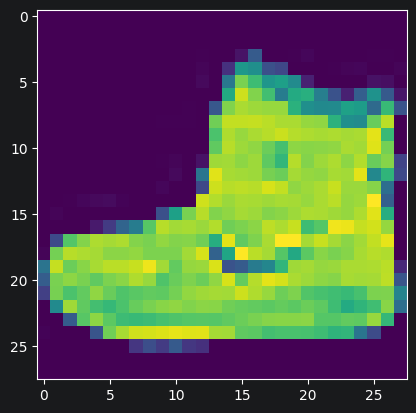

In [19]:
import matplotlib.pyplot as plt
# 打印图片
plt.imshow(mnist[0][0].reshape(28,28)) #现在matplotlib.pyplot支持tensor类型了

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

# 1.确实数据，确定超参数
lr = 0.15
gamma = 0
epochs = 10
batch_size = 128

root = Path.cwd()
mnist = torchvision.datasets.FashionMNIST(
    root=root,
    download=False,
    train=True,
    transform=transforms.ToTensor()
)
dataloader = DataLoader(mnist,batch_size=batch_size,shuffle=True,drop_last=False)
input_ = mnist.data[0].numel() #计算输入层神经元个数，即特征数量
output_ = len(mnist.targets.unique()) #计算输出层神经元个数，即种类数量

# 2.定义神经网络架构
class Model(nn.Module):
    def __init__(self,in_features=10,out_features=2):
        super().__init__()
        self.linear1 = nn.Linear(in_features=in_features,out_features=128,bias=False)
        self.output = nn.Linear(in_features=128,out_features=out_features,bias=False)

    def forward(self,x):
        x = x.reshape(-1,28*28)
        sigma1 = F.relu(self.linear1(x))
        sigma2 = F.log_softmax(self.output(sigma1),dim=1)
        return sigma2

# 3.定义损失函数、优化算法和梯度下降流程->定义一个训练函数(一般叫train或fit)
def fit(model,dataloader,lr=0.01,gamma=0.9,epochs=5,):
    criterion = nn.NLLLoss()
    opt = optim.SGD(model.parameters(),lr=lr,momentum=gamma)

    samples = 0 #记录看过的样本个数，循环开始之前，模型一个样本都没有见过
    correct = 0 #记录预测正确的样本个数，循环开始之前，模型一个样本都没有预测
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_idx,(batch_X,batch_y) in enumerate(dataloader):
            batch_y = batch_y.reshape(len(batch_X)) #整理batch_y结构
            sigma = model(batch_X) #前向传播
            loss = criterion(sigma,batch_y) #计算loss
            loss.backward() #反向传播
            opt.step() #梯度更新
            opt.zero_grad() #梯度清零

            #求解准确率：全部判断正确的样本数量/已经看过的总样本量
            yhat = torch.argmax(sigma,dim=1) #获取最大值对应索引的张量
            correct += (yhat==batch_y).sum()
            samples += len(batch_X) #更新看过的样本个数

            epoch_loss += loss.item() #更新每轮epoch的总loss

            #每125个batch我就打印一次
            if (batch_idx+1)%125 == 0 or batch_idx == len(dataloader)-1:
                total_samples = epochs*len(dataloader.dataset) #所有轮次样本量总和
                progress_pct = 100 * samples/total_samples #进度百分比
                acc_pct = 100 * correct/samples
                print(f"Epoch{epoch+1}: [{samples}/{total_samples} ({progress_pct:.0f}%)], "
                      f"Loss: {loss.item():.6f}, "
                      f"Accuracy: {acc_pct:.3f}")
                #分子代表：已经查看过的数据有多少
                #分母代表：在现有的epochs设置，模型一共需要查看多少数据

        loss_avg = epoch_loss/len(dataloader)
        print(f"{epoch+1}轮loss:{loss_avg}")

# 4.训练与评估
torch.random.manual_seed(420)
model = Model(in_features=input_,out_features=output_)
fit(model,dataloader,lr=lr,gamma=gamma,epochs=epochs)


Epoch1: [16000/600000 (3%)], Loss: 0.677427, Accuracy: 64.738
Epoch1: [32000/600000 (5%)], Loss: 0.634646, Accuracy: 70.806
Epoch1: [48000/600000 (8%)], Loss: 0.486125, Accuracy: 73.842
Epoch1: [60000/600000 (10%)], Loss: 0.476634, Accuracy: 75.215
1轮loss:0.7062516676972924
Epoch2: [76000/600000 (13%)], Loss: 0.583503, Accuracy: 76.720
Epoch2: [92000/600000 (15%)], Loss: 0.417899, Accuracy: 77.786
Epoch2: [108000/600000 (18%)], Loss: 0.480111, Accuracy: 78.571
Epoch2: [120000/600000 (20%)], Loss: 0.461387, Accuracy: 79.151
2轮loss:0.48123791248305264
Epoch3: [136000/600000 (23%)], Loss: 0.519354, Accuracy: 79.750
Epoch3: [152000/600000 (25%)], Loss: 0.419721, Accuracy: 80.321
Epoch3: [168000/600000 (28%)], Loss: 0.476372, Accuracy: 80.782
Epoch3: [180000/600000 (30%)], Loss: 0.372925, Accuracy: 81.072
3轮loss:0.42516892722674776
Epoch4: [196000/600000 (33%)], Loss: 0.513047, Accuracy: 81.459
Epoch4: [212000/600000 (35%)], Loss: 0.304897, Accuracy: 81.801
Epoch4: [228000/600000 (38%)], Lo

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

# ================= 新增：1. 探测并定义计算设备 =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前模型将运行在: {device} 上\n")
# ===============================================================

# 1. 确定数据，确定超参数
lr = 0.15
gamma = 0
epochs = 10
batch_size = 128

root = Path.cwd()
mnist = torchvision.datasets.FashionMNIST(
    root=root,
    download=False,
    train=True,
    transform=transforms.ToTensor()
)
dataloader = DataLoader(mnist, batch_size=batch_size, shuffle=True, drop_last=False)
input_ = mnist.data[0].numel()
output_ = len(mnist.targets.unique())

# 2. 定义神经网络架构
class Model(nn.Module):
    def __init__(self, in_features=10, out_features=2):
        super().__init__()
        self.linear1 = nn.Linear(in_features=in_features, out_features=128, bias=False)
        self.output = nn.Linear(in_features=128, out_features=out_features, bias=False)

    def forward(self, x):
        x = x.reshape(-1, 28*28)
        sigma1 = F.relu(self.linear1(x))
        sigma2 = F.log_softmax(self.output(sigma1), dim=1)
        return sigma2

# 3. 定义训练函数
def fit(model, dataloader, lr=0.01, gamma=0.9, epochs=5):
    criterion = nn.NLLLoss()
    opt = optim.SGD(model.parameters(), lr=lr, momentum=gamma)

    samples = 0
    correct = 0

    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_idx, (batch_X, batch_y) in enumerate(dataloader):

            # ================= 新增：3. 将本批次的数据搬到 GPU 上 =================
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            # ======================================================================

            sigma = model(batch_X) # 前向传播
            loss = criterion(sigma, batch_y) # 计算loss
            loss.backward() # 反向传播
            opt.step() # 梯度更新
            opt.zero_grad() # 梯度清零

            yhat = torch.argmax(sigma, dim=1)
            # 注意这里加上了 .item()，确保累加的是纯数字而不是 GPU 上的标量张量
            correct += (yhat == batch_y).sum().item()
            samples += len(batch_X)

            epoch_loss += loss.item()

            if (batch_idx+1) % 125 == 0 or batch_idx == len(dataloader)-1:
                total_samples = epochs * len(dataloader.dataset)
                progress_pct = 100 * samples / total_samples
                acc_pct = 100 * correct / samples
                print(
                    f"Epoch{epoch+1}: [{samples}/{total_samples} ({progress_pct:.0f}%)], "
                    f"Loss: {loss.item():.6f}, "
                    f"Accuracy: {acc_pct:.3f}"
                )

        loss_avg = epoch_loss / len(dataloader)
        print(f"========== {epoch+1} 轮平均 loss: {loss_avg:.6f} ==========\n")

# 4. 训练与评估
torch.manual_seed(420)
# ================= 新增：2. 将实例化的模型搬到 GPU 上 =================
model = Model(in_features=input_, out_features=output_).to(device)
# ======================================================================

fit(model, dataloader, lr=lr, gamma=gamma, epochs=epochs)

🚀 当前模型将运行在: cuda 上

Epoch1: [16000/600000 (3%)], Loss: 0.677427, Accuracy: 64.737
Epoch1: [32000/600000 (5%)], Loss: 0.634646, Accuracy: 70.806
Epoch1: [48000/600000 (8%)], Loss: 0.486125, Accuracy: 73.842
Epoch1: [60000/600000 (10%)], Loss: 0.477560, Accuracy: 75.220
========== 1 轮平均 loss: 0.706266 ==========

Epoch2: [76000/600000 (13%)], Loss: 0.583511, Accuracy: 76.722
Epoch2: [92000/600000 (15%)], Loss: 0.417277, Accuracy: 77.776
Epoch2: [108000/600000 (18%)], Loss: 0.476078, Accuracy: 78.565
Epoch2: [120000/600000 (20%)], Loss: 0.462934, Accuracy: 79.144
========== 2 轮平均 loss: 0.481030 ==========

Epoch3: [136000/600000 (23%)], Loss: 0.519915, Accuracy: 79.735
Epoch3: [152000/600000 (25%)], Loss: 0.417066, Accuracy: 80.313
Epoch3: [168000/600000 (28%)], Loss: 0.471984, Accuracy: 80.769
Epoch3: [180000/600000 (30%)], Loss: 0.374589, Accuracy: 81.066
========== 3 轮平均 loss: 0.425338 ==========

Epoch4: [196000/600000 (33%)], Loss: 0.498915, Accuracy: 81.452
Epoch4: [212000/600000 (3

In [3]:
# 1. 准备假数据 (全 1 张量)
X = torch.ones(2, 5)

# 2. 实例化Dropout层(设置 50% 概率失活)
model = nn.Dropout(p=0.5)

# 3. 训练模式下的前向传播
model.train() # 默认就是train模式，这里显式声明
output_train = model(X)
print(output_train)
# tensor([[0., 0., 0., 2., 2.],
#         [2., 0., 2., 0., 2.]])
# 大约一半的1.变成了0.且存活下来的1.变成了2.(因为底层乘了1/(1-0.5))

# 4. 测试模式下的前向传播
model.eval()
output_eval = dropout_layer(X)
print(output_eval)
# tensor([[1., 1., 1., 1., 1.],
#         [1., 1., 1., 1., 1.]])
# Dropout彻底罢工，原封不动输出了全1的张量。

tensor([[0., 0., 0., 2., 2.],
        [2., 0., 2., 0., 2.]])
tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])


In [6]:
import torch
import torch.nn as nn

# 1. 准备假数据：5 个样本，每个样本 3 个特征
X = torch.tensor([[100.,  1., 0.],
                  [ 50.,  2., 0.],
                  [200.,  3., 0.],
                  [150.,  4., 0.],
                  [ 80.,  5., 0.]])

# 2. 实例化 BatchNorm1d，特征数为 3
bn = nn.BatchNorm1d(num_features=3)

# 观察初始化的可学习参数和全局统计量
print("初始gamma(weight):", bn.weight.data)       # 全 1
print("初始beta(bias):", bn.bias.data)             # 全 0
print("初始全局均值(running_mean):", bn.running_mean) # 全 0
print("初始全局方差(running_var):", bn.running_var) # 全 1

# 3. 训练模式：前向传播
bn.train()
z_hat = bn(X)
# 第一列 (100,50,200,150,80) 数值非常大经过 BN 后，被强行拉回到了 0 附近！
print("经过 BN 处理后的输出 z_hat:", z_hat)
print("第一列(特征0)的均值变成了:", z_hat[:, 0].mean().item()) # 趋近于 0
print("第一列(特征0)的方差变成了:", z_hat[:, 0].var(unbiased=False).item()) # 趋近于 1
print("初始gamma(weight):", bn.weight.data)
print("初始beta(bias):", bn.bias.data)
print("更新后的全局均值 (running_mean):", bn.running_mean) # 全局均值被隐式更新了
print("更新后的全局方差 (running_var):", bn.running_var) # 全局方差被隐式更新了

# 4. 测试模式
bn.eval()
test_X = torch.tensor([[100., 1., 0.]])
# 在Eval模式下，BN 不会去算这单独1个样本的均值(否则会除以0报错或结果无意义)，
# 而是直接拿刚才训练累积的running_mean和running_var 进行处理。
test_out = bn(test_X)
print(test_out)

初始gamma(weight): tensor([1., 1., 1.])
初始beta(bias): tensor([0., 0., 0.])
初始全局均值(running_mean): tensor([0., 0., 0.])
初始全局方差(running_var): tensor([1., 1., 1.])
经过 BN 处理后的输出 z_hat: tensor([[-0.3011, -1.4142,  0.0000],
        [-1.2420, -0.7071,  0.0000],
        [ 1.5807,  0.0000,  0.0000],
        [ 0.6398,  0.7071,  0.0000],
        [-0.6774,  1.4142,  0.0000]], grad_fn=<NativeBatchNormBackward0>)
第一列(特征0)的均值变成了: -4.7683716530855236e-08
第一列(特征0)的方差变成了: 1.0000001192092896
初始gamma(weight): tensor([1., 1., 1.])
初始beta(bias): tensor([0., 0., 0.])
更新后的全局均值 (running_mean): tensor([11.6000,  0.3000,  0.0000])
更新后的全局方差 (running_var): tensor([353.9000,   1.1500,   0.9000])
tensor([[4.6991, 0.6528, 0.0000]], grad_fn=<NativeBatchNormBackward0>)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

# 1.确实数据，确定超参数
lr = 0.15
gamma = 0
epochs = 10
batch_size = 128

root = Path.cwd()
mnist = torchvision.datasets.FashionMNIST(
    root=root,
    download=False,
    train=True,
    transform=transforms.ToTensor()
)
dataloader = DataLoader(mnist,batch_size=batch_size,shuffle=True,drop_last=False)
input_ = mnist.data[0].numel() #计算输入层神经元个数，即特征数量
output_ = len(mnist.targets.unique()) #计算输出层神经元个数，即种类数量

# 2.定义神经网络架构
class Model(nn.Module):
    def __init__(self,in_features=10,out_features=2):
        super().__init__()
        self.linear1 = nn.Linear(in_features=in_features,out_features=128,bias=False)
        self.bn1 = nn.BatchNorm1d(num_features=128)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(in_features=128,out_features=out_features,bias=False)

    def forward(self,x):
        x = x.reshape(-1,28*28)
        sigma1 = self.linear1(x)        # 1. 先做线性变换
        sigma1 = self.bn1(sigma1)       # 2. 紧接着拉回标准分布 (BN)
        sigma1 = F.relu(sigma1)         # 3. 再过激活函数
        sigma1 = self.dropout(sigma1)   # 4. 最后随机失活一部分神经元
        sigma2 = F.log_softmax(self.output(sigma1),dim=1)
        return sigma2

# 3.定义损失函数、优化算法和梯度下降流程->定义一个训练函数(一般叫train或fit)
def fit(model,dataloader,lr=0.01,gamma=0.9,epochs=5,):
    criterion = nn.NLLLoss()
    opt = optim.SGD(model.parameters(),lr=lr,momentum=gamma)

    samples = 0 #记录看过的样本个数，循环开始之前，模型一个样本都没有见过
    correct = 0 #记录预测正确的样本个数，循环开始之前，模型一个样本都没有预测
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_idx,(batch_X,batch_y) in enumerate(dataloader):
            batch_y = batch_y.reshape(len(batch_X)) #整理batch_y结构
            sigma = model(batch_X) #前向传播
            loss = criterion(sigma,batch_y) #计算loss
            loss.backward() #反向传播
            opt.step() #梯度更新
            opt.zero_grad() #梯度清零

            #求解准确率：全部判断正确的样本数量/已经看过的总样本量
            yhat = torch.argmax(sigma,dim=1) #获取最大值对应索引的张量
            correct += (yhat==batch_y).sum().item()
            samples += len(batch_X) #更新看过的样本个数

            epoch_loss += loss.item() #更新每轮epoch的总loss

            #每125个batch我就打印一次
            if (batch_idx+1)%125 == 0 or batch_idx == len(dataloader)-1:
                total_samples = epochs*len(dataloader.dataset) #所有轮次样本量总和
                progress_pct = 100 * samples/total_samples #进度百分比
                acc_pct = 100 * correct/samples
                print(f"Epoch{epoch+1}: [{samples}/{total_samples} ({progress_pct:.0f}%)], "
                      f"Loss: {loss.item():.6f}, "
                      f"Accuracy: {acc_pct:.3f}")
                #分子代表：已经查看过的数据有多少
                #分母代表：在现有的epochs设置，模型一共需要查看多少数据

        loss_avg = epoch_loss/len(dataloader)
        print(f"{epoch+1}轮loss:{loss_avg}")

# 4.训练与评估
torch.random.manual_seed(420)
model = Model(in_features=input_,out_features=output_)
fit(model,dataloader,lr=lr,gamma=gamma,epochs=epochs)

Epoch1: [16000/600000 (3%)], Loss: 0.469969, Accuracy: 77.438
Epoch1: [32000/600000 (5%)], Loss: 0.523475, Accuracy: 79.753
Epoch1: [48000/600000 (8%)], Loss: 0.462733, Accuracy: 80.883
Epoch1: [60000/600000 (10%)], Loss: 0.404814, Accuracy: 81.493
1轮loss:0.5276521389037053
Epoch2: [76000/600000 (13%)], Loss: 0.500347, Accuracy: 82.126
Epoch2: [92000/600000 (15%)], Loss: 0.522467, Accuracy: 82.764
Epoch2: [108000/600000 (18%)], Loss: 0.311655, Accuracy: 83.144
Epoch2: [120000/600000 (20%)], Loss: 0.355782, Accuracy: 83.378
2轮loss:0.4139585699925799
Epoch3: [136000/600000 (23%)], Loss: 0.341515, Accuracy: 83.723
Epoch3: [152000/600000 (25%)], Loss: 0.429800, Accuracy: 84.012
Epoch3: [168000/600000 (28%)], Loss: 0.452742, Accuracy: 84.220
Epoch3: [180000/600000 (30%)], Loss: 0.285456, Accuracy: 84.384
3轮loss:0.38145666253337984
Epoch4: [196000/600000 (33%)], Loss: 0.362003, Accuracy: 84.576
Epoch4: [212000/600000 (35%)], Loss: 0.404659, Accuracy: 84.783
Epoch4: [228000/600000 (38%)], Los

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

# 1.确实数据，确定超参数
lr = 0.15
gamma = 0
epochs = 10
batch_size = 128

root = Path.cwd()
mnist = torchvision.datasets.FashionMNIST(
    root=root,
    download=False,
    train=True,
    transform=transforms.ToTensor()
)
dataloader = DataLoader(mnist,batch_size=batch_size,shuffle=True,drop_last=False)
input_ = mnist.data[0].numel() #计算输入层神经元个数，即特征数量
output_ = len(mnist.targets.unique()) #计算输出层神经元个数，即种类数量

# 2.定义神经网络架构
class Model(nn.Module):
    def __init__(self,in_features=10,out_features=2):
        super().__init__()
        self.linear1 = nn.Linear(in_features=in_features,out_features=128,bias=False)
        self.bn1 = nn.BatchNorm1d(num_features=128)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(in_features=128,out_features=out_features,bias=False)

    def forward(self,x):
        x = x.reshape(-1,28*28)
        sigma1 = self.linear1(x)        # 1. 先做线性变换
        sigma1 = self.bn1(sigma1)       # 2. 紧接着拉回标准分布 (BN)
        sigma1 = F.relu(sigma1)         # 3. 再过激活函数
        sigma1 = self.dropout(sigma1)   # 4. 最后随机失活一部分神经元
        sigma2 = F.log_softmax(self.output(sigma1),dim=1)
        return sigma2

# 3.定义损失函数、优化算法和梯度下降流程->定义一个训练函数(一般叫train或fit)
def fit(model,dataloader,device,lr=0.01,gamma=0.9,epochs=5,):
    criterion = nn.NLLLoss()
    opt = optim.SGD(model.parameters(),lr=lr,momentum=gamma)

    samples = 0 #记录看过的样本个数，循环开始之前，模型一个样本都没有见过
    correct = 0 #记录预测正确的样本个数，循环开始之前，模型一个样本都没有预测
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_idx,(batch_X,batch_y) in enumerate(dataloader):
            batch_y = batch_y.reshape(len(batch_X)) #整理batch_y结构
            # 数据搬到GPU
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            sigma = model(batch_X) #前向传播
            loss = criterion(sigma,batch_y) #计算loss
            loss.backward() #反向传播
            opt.step() #梯度更新
            opt.zero_grad() #梯度清零

            #求解准确率：全部判断正确的样本数量/已经看过的总样本量
            yhat = torch.argmax(sigma,dim=1) #获取最大值对应索引的张量
            correct += (yhat==batch_y).sum().item()
            samples += len(batch_X) #更新看过的样本个数

            epoch_loss += loss.item() #更新每轮epoch的总loss

            #每125个batch我就打印一次
            if (batch_idx+1)%125 == 0 or batch_idx == len(dataloader)-1:
                total_samples = epochs*len(dataloader.dataset) #所有轮次样本量总和
                progress_pct = 100 * samples/total_samples #进度百分比
                acc_pct = 100 * correct/samples
                print(f"Epoch{epoch+1}: [{samples}/{total_samples} ({progress_pct:.0f}%)], "
                      f"Loss: {loss.item():.6f}, "
                      f"Accuracy: {acc_pct:.3f}")
                #分子代表：已经查看过的数据有多少
                #分母代表：在现有的epochs设置，模型一共需要查看多少数据

        loss_avg = epoch_loss/len(dataloader)
        print(f"{epoch+1}轮loss:{loss_avg}")

# 4.训练与评估
torch.random.manual_seed(420)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device:{device}")
model = Model(in_features=input_,out_features=output_)
model = model.to(device)
fit(model,dataloader,device,lr=lr,gamma=gamma,epochs=epochs)

device:cuda
Epoch1: [16000/600000 (3%)], Loss: 0.505364, Accuracy: 76.875
Epoch1: [32000/600000 (5%)], Loss: 0.502231, Accuracy: 79.525
Epoch1: [48000/600000 (8%)], Loss: 0.414066, Accuracy: 80.779
Epoch1: [60000/600000 (10%)], Loss: 0.419336, Accuracy: 81.420
1轮loss:0.528286550027221
Epoch2: [76000/600000 (13%)], Loss: 0.475275, Accuracy: 82.218
Epoch2: [92000/600000 (15%)], Loss: 0.364501, Accuracy: 82.736
Epoch2: [108000/600000 (18%)], Loss: 0.414584, Accuracy: 83.125
Epoch2: [120000/600000 (20%)], Loss: 0.424715, Accuracy: 83.372
2轮loss:0.4124135530706662
Epoch3: [136000/600000 (23%)], Loss: 0.416911, Accuracy: 83.649
Epoch3: [152000/600000 (25%)], Loss: 0.398592, Accuracy: 83.945
Epoch3: [168000/600000 (28%)], Loss: 0.478080, Accuracy: 84.196
Epoch3: [180000/600000 (30%)], Loss: 0.381861, Accuracy: 84.338
3轮loss:0.3830376665221094
Epoch4: [196000/600000 (33%)], Loss: 0.428084, Accuracy: 84.569
Epoch4: [212000/600000 (35%)], Loss: 0.359894, Accuracy: 84.757
Epoch4: [228000/600000 (